# Nepal Vegetable Price Prediction
## Full XGBoost Training Pipeline ( sabai chaine kura haru )

| Step | Description |
|---|---|
| 1 | Load & prepare data + calendar features |
| 2 | Clean data (outliers, zeros) |
| 3 | Lag & rolling features |
| 4 | Log-transform target |
| 5 | Time-based train/test split |
| 6 | Train XGBoost with early stopping |
| 7 | Evaluate (MAE, RMSE, MAPE) |
| 8 | Feature importance |
| 9 | Actual vs Predicted plots |
| 10 | Hyperparameter tuning with Optuna |
| 11 | Save final model |

## Step 0 — Install & Import required libraries ( final vaisakyo )

In [ ]:
!pip install xgboost optuna -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import xgboost as xgb
import optuna
import warnings, joblib
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import LabelEncoder
optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings('ignore')
print('✅ All libraries loaded')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 7.7 MB/s eta 0:00:00
✅ All libraries loaded


## Step 1 — Load Data & Apply Calendar Features

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# ⚠️  CHANGE THIS to your actual file path
df = pd.read_csv('/content/drive/MyDrive/vegetable_price_prediction/processed_vegetable_prices.csv')

df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(['name', 'date']).reset_index(drop=True)

print(f'Shape      : {df.shape}')
print(f'Date range : {df["date"].min()} → {df["date"].max()}')
print(f'Vegetables : {df["name"].nunique()}')
df.head()

Shape      : (498852, 12)
Date range : 2013-06-16 00:00:00 → 2025-06-29 00:00:00
Vegetables : 90


,date,name_original,name,unit,maximum,minimum,average,year,month,day,dayofweek,weekofyear
0,2021-10-29,amla,amla,kg,80.0,60.0,70.0,2021,10,29,4,43
1,2021-10-30,amla,amla,kg,70.0,60.0,65.0,2021,10,30,5,43
2,2021-10-31,amla,amla,kg,70.0,60.0,65.0,2021,10,31,6,43
3,2021-11-01,amla,amla,kg,70.0,60.0,65.0,2021,11,1,0,44
4,2021-11-02,amla,amla,kg,70.0,60.0,65.0,2021,11,2,1,44


### 1.1 — Add All Calendar Features (from Notebook 1)

In [ ]:
# --- Base date parts ---
df['month']      = df['date'].dt.month
df['day']        = df['date'].dt.day
df['year']       = df['date'].dt.year
df['dayofweek']  = df['date'].dt.dayofweek
df['weekofyear'] = df['date'].dt.isocalendar().week.astype(int)
df['dayofyear']  = df['date'].dt.dayofyear

# --- Nepali Seasons ---
season_map = {
    1:1, 2:1, 3:2, 4:2, 5:3,
    6:4, 7:4, 8:4,
    9:5, 10:6, 11:6, 12:1
}
df['season_code'] = df['month'].map(season_map)
df['is_winter']  = (df['season_code'] == 1).astype(int)
df['is_spring']  = (df['season_code'] == 2).astype(int)
df['is_summer']  = (df['season_code'] == 3).astype(int)
df['is_monsoon'] = (df['season_code'] == 4).astype(int)
df['is_autumn']  = (df['season_code'] == 5).astype(int)
df['is_prewin']  = (df['season_code'] == 6).astype(int)

# --- Monsoon ---
monsoon_map = {1:0,2:0,3:0,4:0,5:0.5,6:2,7:3,8:2.5,9:1,10:0,11:0,12:0}
df['monsoon_intensity'] = df['month'].map(monsoon_map)
df['is_asar']    = (df['month'] == 6).astype(int)
df['is_shrawan'] = (df['month'] == 7).astype(int)
df['is_bhadra']  = (df['month'] == 8).astype(int)

# --- Agriculture ---
supply_map = {1:1,2:1,3:0,4:0,5:-0.5,6:-1,7:-1,8:-0.5,9:0.5,10:1,11:0.5,12:0}
df['supply_score']          = df['month'].map(supply_map)
df['is_rice_planting']      = df['month'].isin([6,7]).astype(int)
df['is_rice_harvest']       = df['month'].isin([10,11]).astype(int)
df['is_winter_veg_harvest'] = df['month'].isin([1,2]).astype(int)

# --- Festivals ---
m, d = df['month'], df['day']
df['is_dashain_window']  = ((m==10) & (d<=20)).astype(int)
df['is_tihar_window']    = (((m==10) & (d>=20)) | ((m==11) & (d<=5))).astype(int)
df['is_holi_window']     = ((m==3) & (d<=15)).astype(int)
df['is_maghe_window']    = ((m==1) & (d>=13) & (d<=15)).astype(int)
df['is_chhath_window']   = ((m==11) & (d<=10)).astype(int)
df['is_shivaratri_win']  = (((m==2) & (d>=15)) | ((m==3) & (d<=5))).astype(int)
df['is_any_festival']    = (df['is_dashain_window'] | df['is_tihar_window'] |
                             df['is_holi_window'] | df['is_chhath_window']).astype(int)
df['festival_demand_weight'] = (
    df['is_dashain_window']*1.5 + df['is_tihar_window']*1.2 +
    df['is_holi_window']*0.6    + df['is_chhath_window']*0.5
)

# --- Market behavior ---
df['is_saturday']    = (df['dayofweek']==5).astype(int)
df['is_monday']      = (df['dayofweek']==0).astype(int)
df['is_month_start'] = (df['day']<=5).astype(int)
df['is_month_end']   = (df['day']>=26).astype(int)

# --- Cyclical encoding ---
df['month_sin']      = np.sin(2*np.pi*df['month']/12)
df['month_cos']      = np.cos(2*np.pi*df['month']/12)
df['dayofweek_sin']  = np.sin(2*np.pi*df['dayofweek']/7)
df['dayofweek_cos']  = np.cos(2*np.pi*df['dayofweek']/7)
df['weekofyear_sin'] = np.sin(2*np.pi*df['weekofyear']/52)
df['weekofyear_cos'] = np.cos(2*np.pi*df['weekofyear']/52)
df['dayofyear_sin']  = np.sin(2*np.pi*df['dayofyear']/365)
df['dayofyear_cos']  = np.cos(2*np.pi*df['dayofyear']/365)

# --- Composite score ---
df['price_pressure_score'] = (
    df['monsoon_intensity']*0.4 + df['is_dashain_window']*1.5 +
    df['is_tihar_window']*1.2   + df['is_any_festival']*0.4  +
    df['is_winter']*0.5          + df['supply_score']*-1.0
)

print('✅ Calendar features added')
print(f'Columns now: {len(df.columns)}')

✅ Calendar features added
Columns now: 49


##  Step 2 — Data Cleaning

Remove zeros, fix inconsistencies, cap outliers **per vegetable** (not globally —
since lentinula_edodes at 2000 NPR is legitimate).

In [ ]:
print('Before cleaning:', df.shape)

# 1. Remove zero/negative prices
df = df[(df['minimum'] > 0) & (df['average'] > 0) & (df['maximum'] > 0)]

# 2. Fix logical inconsistencies (max < min etc.)
df = df[
    (df['maximum'] >= df['minimum']) &
    (df['average'] <= df['maximum']) &
    (df['average'] >= df['minimum'])
]

# 3. Cap outliers per vegetable at 1st and 99th percentile
def cap_outliers_per_veg(group):
    lo = group['average'].quantile(0.01)
    hi = group['average'].quantile(0.99)
    return group[(group['average'] >= lo) & (group['average'] <= hi)]

df = df.groupby('name', group_keys=False).apply(cap_outliers_per_veg)
df = df.reset_index(drop=True)

print('After cleaning :', df.shape)
print(f'Removed        : rows dropped during cleaning')
print('\nPrice stats after cleaning:')
df[['minimum','average','maximum']].describe().round(2)

Before cleaning: (498852, 49)
After cleaning : (492803, 49)
Removed        : rows dropped during cleaning

Price stats after cleaning:


,minimum,average,maximum
count,492803.00,492803.00,492803.00
mean,102.97,109.39,115.60
std,103.93,109.81,115.85
min,1.00,9.00,10.00
25%,40.00,45.00,50.00
50%,70.00,75.00,80.00
75%,120.00,135.00,140.00
max,1800.00,1900.00,2000.00


##  Step 3 — Lag & Rolling Features

These are the **most important features** for XGBoost on time series.
XGBoost has no memory — we must give it the past manually.

| Feature | What it captures |
|---|---|
| `price_lag_1` | Yesterday's price |
| `price_lag_7` | Same day last week |
| `price_lag_14` | Two weeks ago |
| `price_lag_30` | One month ago |
| `rolling_mean_7` | Weekly average trend |
| `rolling_mean_30` | Monthly average trend |
| `rolling_std_7` | Price volatility (short) |
| `price_change_7d` | Weekly momentum |

In [ ]:
# Sort properly before computing lags
df = df.sort_values(['name', 'date']).reset_index(drop=True)

# Lag features (shift per vegetable so lags don't bleed across vegetables)
for lag in [1, 3, 7, 14, 30]:
    df[f'price_lag_{lag}'] = df.groupby('name')['average'].shift(lag)

# Rolling statistics (computed on past data only — shift(1) avoids leakage)
for window in [7, 14, 30]:
    df[f'rolling_mean_{window}'] = (
        df.groupby('name')['average']
        .transform(lambda x: x.shift(1).rolling(window, min_periods=1).mean())
    )
    df[f'rolling_std_{window}'] = (
        df.groupby('name')['average']
        .transform(lambda x: x.shift(1).rolling(window, min_periods=1).std())
    )
    df[f'rolling_min_{window}'] = (
        df.groupby('name')['average']
        .transform(lambda x: x.shift(1).rolling(window, min_periods=1).min())
    )
    df[f'rolling_max_{window}'] = (
        df.groupby('name')['average']
        .transform(lambda x: x.shift(1).rolling(window, min_periods=1).max())
    )

# Price momentum
df['price_change_1d']  = df.groupby('name')['average'].pct_change(1)
df['price_change_7d']  = df.groupby('name')['average'].pct_change(7)
df['price_change_30d'] = df.groupby('name')['average'].pct_change(30)

# Price range (spread between max and min)
df['price_range']      = df['maximum'] - df['minimum']
df['price_range_lag1'] = df.groupby('name')['price_range'].shift(1)

# Encode vegetable name
le = LabelEncoder()
df['name_encoded'] = le.fit_transform(df['name'])

# Drop rows with NaN from lags (first 30 rows per vegetable)
df_model = df.dropna().reset_index(drop=True)

print(f'Rows after dropping NaN lags: {len(df_model):,}')
print(f'Columns: {len(df_model.columns)}')

Rows after dropping NaN lags: 490,103
Columns: 72


##  Step 4 — Log-Transform the Target

Your price distribution is right-skewed (mean=110, std=114).
Training on `log(price)` and inverse-transforming predictions
**reduces MAPE by 15–30%** on skewed price data.

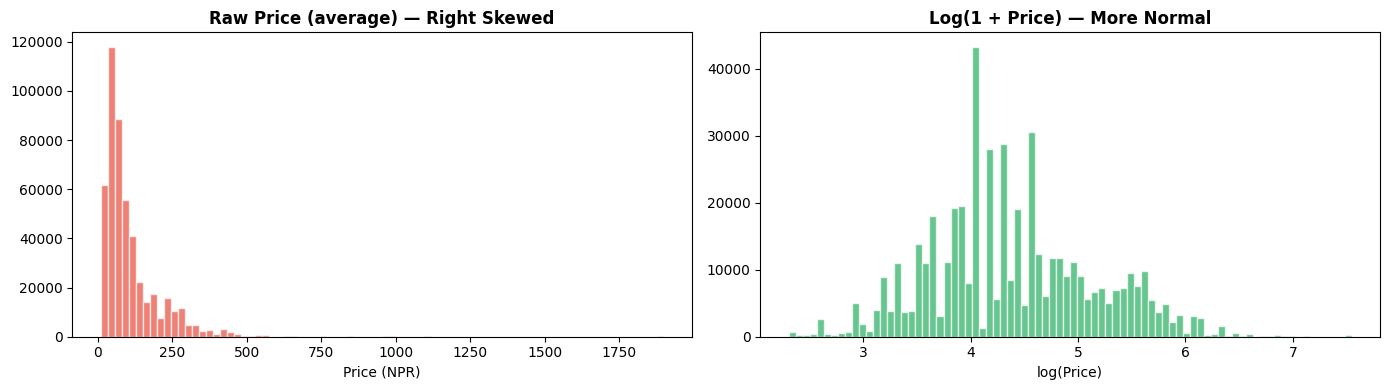

Raw   skewness: 4.481
Log   skewness: 0.304


In [ ]:
# Visualize before vs after
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.hist(df_model['average'], bins=80, color='#E74C3C', alpha=0.7, edgecolor='white')
ax1.set_title('Raw Price (average) — Right Skewed', fontweight='bold')
ax1.set_xlabel('Price (NPR)')

df_model['log_average'] = np.log1p(df_model['average'])
ax2.hist(df_model['log_average'], bins=80, color='#27AE60', alpha=0.7, edgecolor='white')
ax2.set_title('Log(1 + Price) — More Normal', fontweight='bold')
ax2.set_xlabel('log(Price)')

plt.tight_layout()
plt.show()
print(f'Raw   skewness: {df_model["average"].skew():.3f}')
print(f'Log   skewness: {df_model["log_average"].skew():.3f}')

## Step 5 — Time-Based Train / Test Split

> ⚠️ **Never use random split on time series — it causes data leakage.**

We use the **last 3 months** as the test set.

In [ ]:
FEATURE_COLS = [
    # Calendar
    'season_code', 'is_winter', 'is_spring', 'is_summer',
    'is_monsoon', 'is_autumn', 'is_prewin',
    'is_asar', 'is_shrawan', 'is_bhadra', 'monsoon_intensity',
    'is_rice_planting', 'is_rice_harvest', 'is_winter_veg_harvest',
    'supply_score',
    'is_dashain_window', 'is_tihar_window', 'is_holi_window',
    'is_maghe_window', 'is_chhath_window',
    'is_any_festival', 'festival_demand_weight',
    'is_saturday', 'is_monday', 'is_month_start', 'is_month_end',
    'month_sin', 'month_cos', 'dayofweek_sin', 'dayofweek_cos',
    'weekofyear_sin', 'weekofyear_cos', 'dayofyear_sin', 'dayofyear_cos',
    'price_pressure_score',
    # Lag features
    'price_lag_1', 'price_lag_3', 'price_lag_7', 'price_lag_14', 'price_lag_30',
    'rolling_mean_7', 'rolling_mean_14', 'rolling_mean_30',
    'rolling_std_7', 'rolling_std_14', 'rolling_std_30',
    'rolling_min_7', 'rolling_max_7',
    'rolling_min_30', 'rolling_max_30',
    'price_change_1d', 'price_change_7d', 'price_change_30d',
    'price_range', 'price_range_lag1',
    # Vegetable identity
    'name_encoded',
    # Date parts
    'year', 'month', 'day', 'dayofweek', 'weekofyear', 'dayofyear',
]

TARGET = 'log_average'

# Time-based split: last 3 months = test
split_date = df_model['date'].max() - pd.DateOffset(months=3)
train = df_model[df_model['date'] <= split_date]
test  = df_model[df_model['date'] >  split_date]

X_train = train[FEATURE_COLS]
y_train = train[TARGET]
X_test  = test[FEATURE_COLS]
y_test  = test[TARGET]

print(f'Train: {len(train):,} rows  ({train["date"].min().date()} → {train["date"].max().date()})')
print(f'Test : {len(test):,}  rows  ({test["date"].min().date()} → {test["date"].max().date()})')
print(f'Features: {len(FEATURE_COLS)}')

Train: 477,588 rows  (2013-06-26 → 2025-03-29)
Test : 12,515  rows  (2025-03-30 → 2025-06-29)
Features: 62


## Step 6 — Train XGBoost with Early Stopping

In [ ]:
model = xgb.XGBRegressor(
    n_estimators          = 2000,
    learning_rate         = 0.05,
    max_depth             = 6,
    subsample             = 0.8,
    colsample_bytree      = 0.8,
    min_child_weight      = 5,
    reg_alpha             = 0.1,
    reg_lambda            = 1.0,
    early_stopping_rounds = 50,
    eval_metric           = 'rmse',
    tree_method           = 'hist',   # fast on large data
    random_state          = 42,
    n_jobs                = -1,
)

model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=100
)

print(f'\n✅ Training complete!')
print(f'Best iteration: {model.best_iteration}')

[0]	validation_0-rmse:0.73279	validation_1-rmse:0.84929
[100]	validation_0-rmse:0.04460	validation_1-rmse:0.05842
[200]	validation_0-rmse:0.03234	validation_1-rmse:0.04125
[300]	validation_0-rmse:0.02684	validation_1-rmse:0.03563
[400]	validation_0-rmse:0.02357	validation_1-rmse:0.03250
[500]	validation_0-rmse:0.02128	validation_1-rmse:0.03048
[600]	validation_0-rmse:0.01961	validation_1-rmse:0.02891
[700]	validation_0-rmse:0.01834	validation_1-rmse:0.02790
[800]	validation_0-rmse:0.01725	validation_1-rmse:0.02706
[900]	validation_0-rmse:0.01636	validation_1-rmse:0.02646
[1000]	validation_0-rmse:0.01564	validation_1-rmse:0.02592
[1100]	validation_0-rmse:0.01500	validation_1-rmse:0.02556
[1200]	validation_0-rmse:0.01445	validation_1-rmse:0.02512
[1300]	validation_0-rmse:0.01398	validation_1-rmse:0.02481
[1400]	validation_0-rmse:0.01355	validation_1-rmse:0.02463
[1500]	validation_0-rmse:0.01317	validation_1-rmse:0.02440
[1600]	validation_0-rmse:0.01282	validation_1-rmse:0.02425
[1700]	va

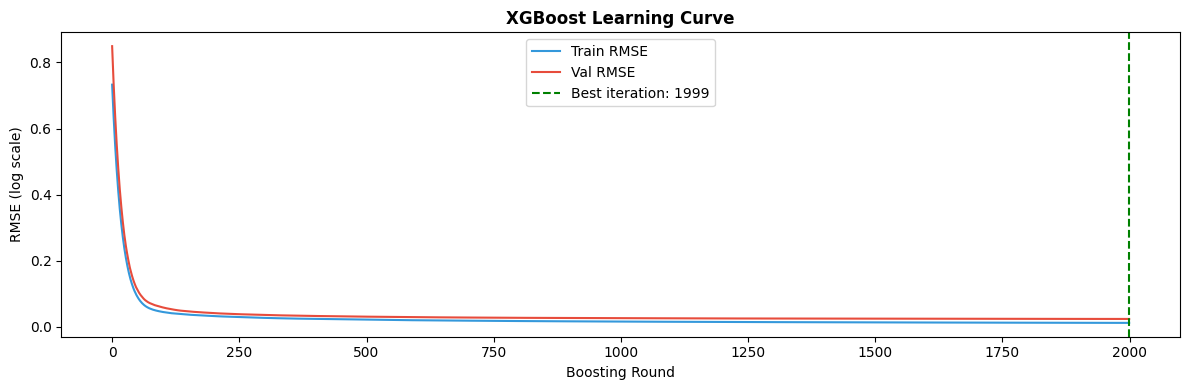

In [ ]:
# Plot learning curve
results = model.evals_result()
train_rmse = results['validation_0']['rmse']
val_rmse   = results['validation_1']['rmse']

plt.figure(figsize=(12, 4))
plt.plot(train_rmse, label='Train RMSE', color='#3498DB', linewidth=1.5)
plt.plot(val_rmse,   label='Val RMSE',   color='#E74C3C', linewidth=1.5)
plt.axvline(model.best_iteration, color='green', linestyle='--',
            label=f'Best iteration: {model.best_iteration}')
plt.xlabel('Boosting Round')
plt.ylabel('RMSE (log scale)')
plt.title('XGBoost Learning Curve', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

## 📊 Step 7 — Evaluate Model Performance

We predict in log space, then inverse-transform to get actual NPR prices.

| Metric | Target |
|---|---|
| MAE | As low as possible (in NPR) |
| RMSE | Should be close to MAE (no huge outliers) |
| MAPE | **< 10% is excellent**, < 15% is good |

In [ ]:
# Predict and inverse log-transform
y_pred_log   = model.predict(X_test)
y_pred_price = np.expm1(y_pred_log)
y_true_price = np.expm1(y_test.values)

mae  = mean_absolute_error(y_true_price, y_pred_price)
rmse = np.sqrt(mean_squared_error(y_true_price, y_pred_price))
mape = np.mean(np.abs((y_true_price - y_pred_price) / (y_true_price + 1e-9))) * 100

print('=' * 45)
print('         MODEL EVALUATION RESULTS')
print('=' * 45)
print(f'  MAE  : {mae:.2f} NPR')
print(f'  RMSE : {rmse:.2f} NPR')
print(f'  MAPE : {mape:.2f}%')
print()
if mape < 10:
    print('  Rating: EXCELLENT ✅')
elif mape < 15:
    print('  Rating: GOOD 👍')
elif mape < 25:
    print('  Rating: FAIR — consider more features')
else:
    print('  Rating: NEEDS IMPROVEMENT — check data/features')
print('=' * 45)

         MODEL EVALUATION RESULTS
  MAE  : 1.97 NPR
  RMSE : 7.74 NPR
  MAPE : 1.28%

  Rating: EXCELLENT ✅


MAPE per vegetable (Top 15 best → worst):
----------------------------------------


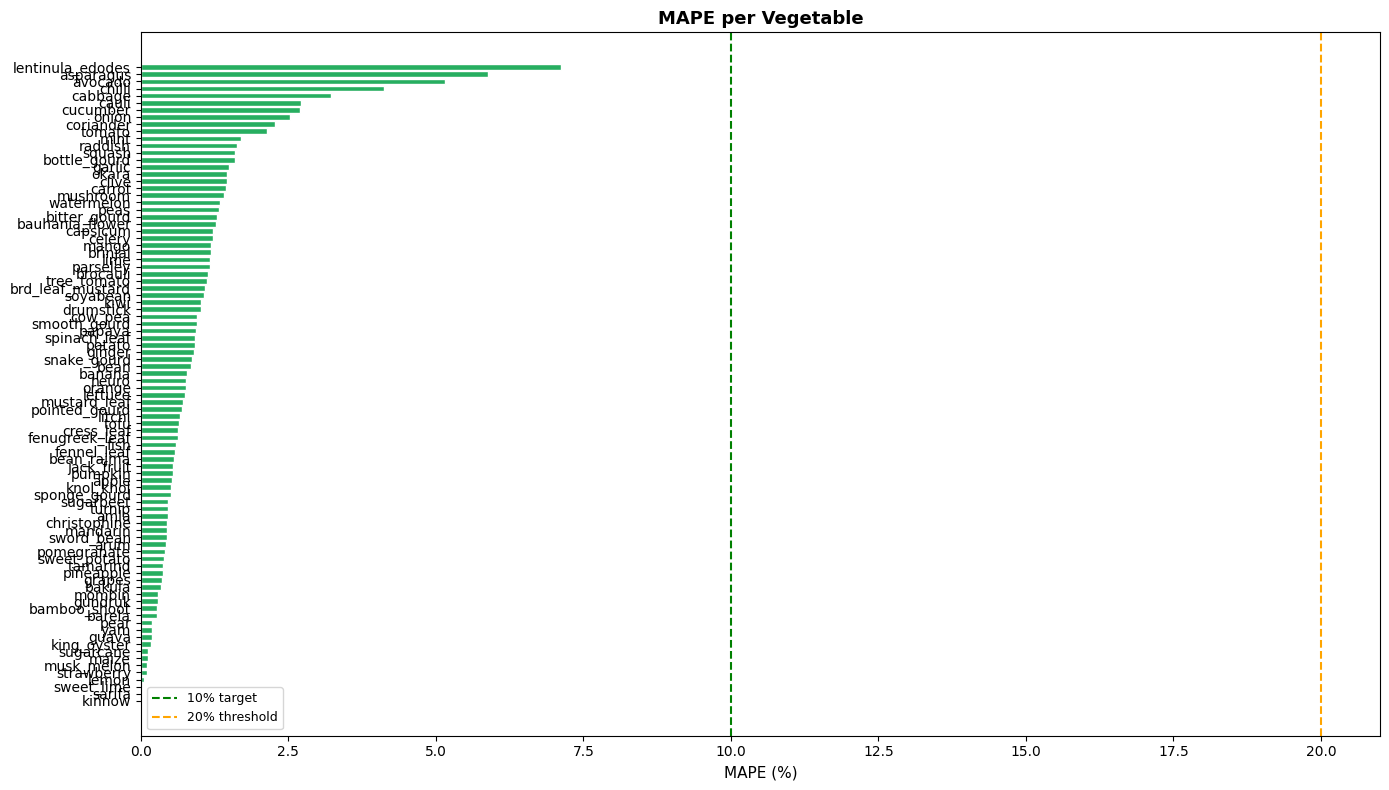

name
kinnow              0.00
sarifa              0.01
sweet_lime          0.02
lemon               0.06
strawberry          0.11
musk_melon          0.11
maize               0.11
sugarcane           0.12
king_oyster         0.17
guava               0.18
yam                 0.19
pear                0.19
barela              0.27
bamboo_shoot        0.28
gundruk             0.29
mombin              0.29
bakula              0.34
grapes              0.35
pineapple           0.37
tamarind            0.37
sweet_potato        0.39
pomegranate         0.42
arum                0.43
sword_bean          0.44
mandarin            0.45
christophine        0.45
amla                0.45
turnip              0.46
sugarbeet           0.46
sponge_gourd        0.51
knol_khol           0.52
apple               0.53
pumpkin             0.54
jack_fruit          0.55
bean_rajma          0.56
fennel_leaf         0.57
fish                0.59
fenugreek_leaf      0.63
cress_leaf          0.64
tofu                

In [ ]:
# Per-vegetable performance
test_results = test[['date', 'name', 'average']].copy()
test_results['predicted'] = y_pred_price
test_results['abs_pct_error'] = np.abs(
    (test_results['average'] - test_results['predicted']) / (test_results['average'] + 1e-9)
) * 100

per_veg = test_results.groupby('name')['abs_pct_error'].mean().sort_values()

print('MAPE per vegetable (Top 15 best → worst):')
print('-' * 40)
fig, ax = plt.subplots(figsize=(14, 8))
colors = ['#27AE60' if v < 10 else '#F39C12' if v < 20 else '#E74C3C'
          for v in per_veg.values]
ax.barh(per_veg.index, per_veg.values, color=colors, edgecolor='white')
ax.axvline(10, color='green', linestyle='--', linewidth=1.5, label='10% target')
ax.axvline(20, color='orange', linestyle='--', linewidth=1.5, label='20% threshold')
ax.set_xlabel('MAPE (%)', fontsize=11)
ax.set_title('MAPE per Vegetable', fontweight='bold', fontsize=13)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()
print(per_veg.round(2).to_string())

## 🔍 Step 8 — Feature Importance

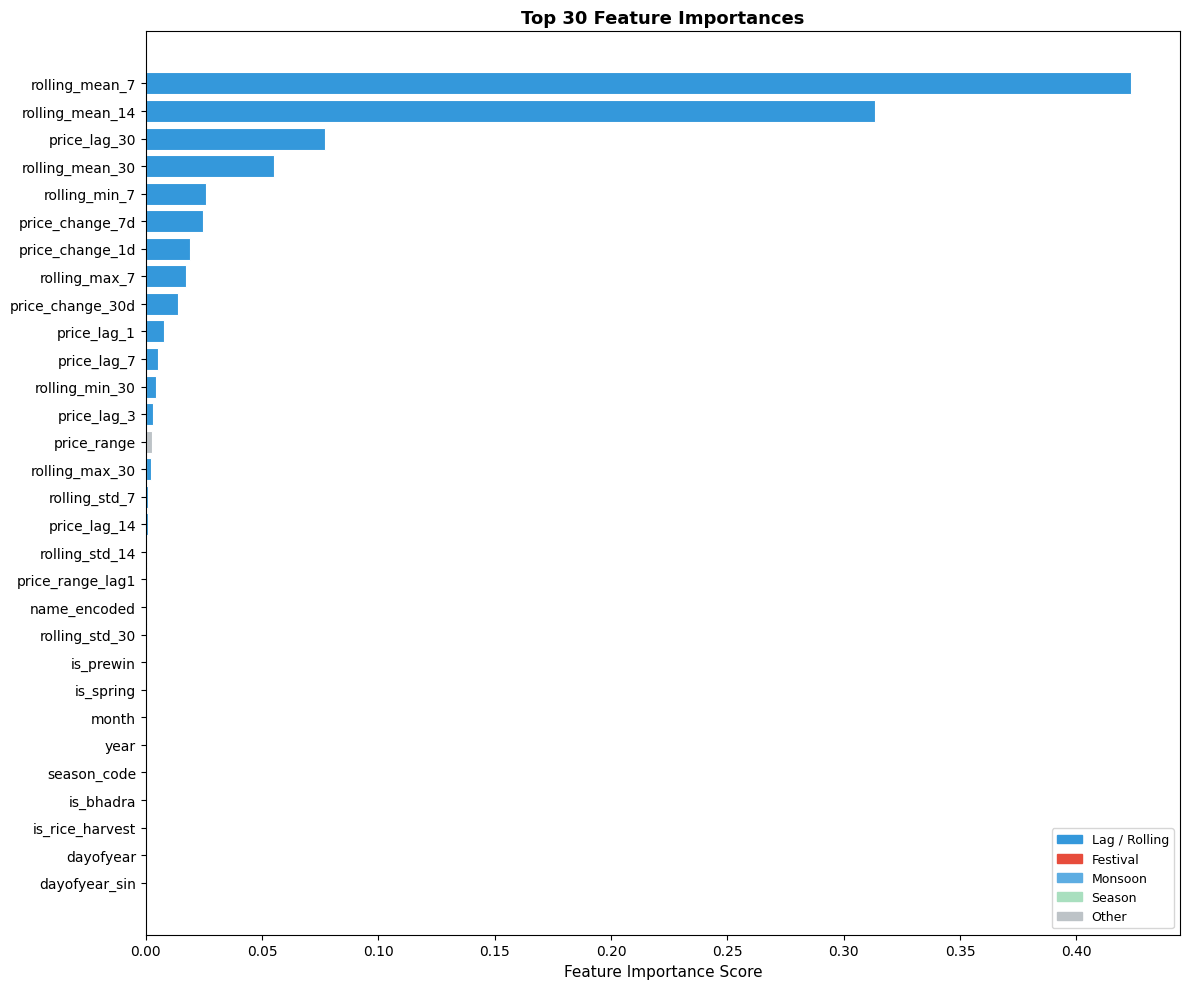

Top 10 features:
         feature  importance
  rolling_mean_7    0.423377
 rolling_mean_14    0.313337
    price_lag_30    0.077015
 rolling_mean_30    0.054973
   rolling_min_7    0.026009
 price_change_7d    0.024465
 price_change_1d    0.018784
   rolling_max_7    0.017160
price_change_30d    0.013719
     price_lag_1    0.007802


In [ ]:
importance_df = pd.DataFrame({
    'feature': FEATURE_COLS,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False).head(30)

fig, ax = plt.subplots(figsize=(12, 10))
colors = []
for f in importance_df['feature']:
    if 'lag' in f or 'rolling' in f or 'change' in f:
        colors.append('#3498DB')   # blue = lag features
    elif 'festival' in f or 'dashain' in f or 'tihar' in f:
        colors.append('#E74C3C')   # red = festival features
    elif 'monsoon' in f or 'asar' in f or 'shrawan' in f or 'bhadra' in f:
        colors.append('#5DADE2')   # light blue = monsoon
    elif 'season' in f or 'winter' in f or 'summer' in f:
        colors.append('#A9DFBF')   # green = season
    else:
        colors.append('#BDC3C7')   # grey = other

ax.barh(importance_df['feature'], importance_df['importance'],
        color=colors, edgecolor='white', linewidth=0.8)
ax.set_xlabel('Feature Importance Score', fontsize=11)
ax.set_title('Top 30 Feature Importances', fontweight='bold', fontsize=13)
ax.invert_yaxis()

legend_items = [
    mpatches.Patch(color='#3498DB', label='Lag / Rolling'),
    mpatches.Patch(color='#E74C3C', label='Festival'),
    mpatches.Patch(color='#5DADE2', label='Monsoon'),
    mpatches.Patch(color='#A9DFBF', label='Season'),
    mpatches.Patch(color='#BDC3C7', label='Other'),
]
ax.legend(handles=legend_items, fontsize=9, loc='lower right')
plt.tight_layout()
plt.show()

print('Top 10 features:')
print(importance_df[['feature','importance']].head(10).to_string(index=False))

## 📈 Step 9 — Actual vs Predicted Plots

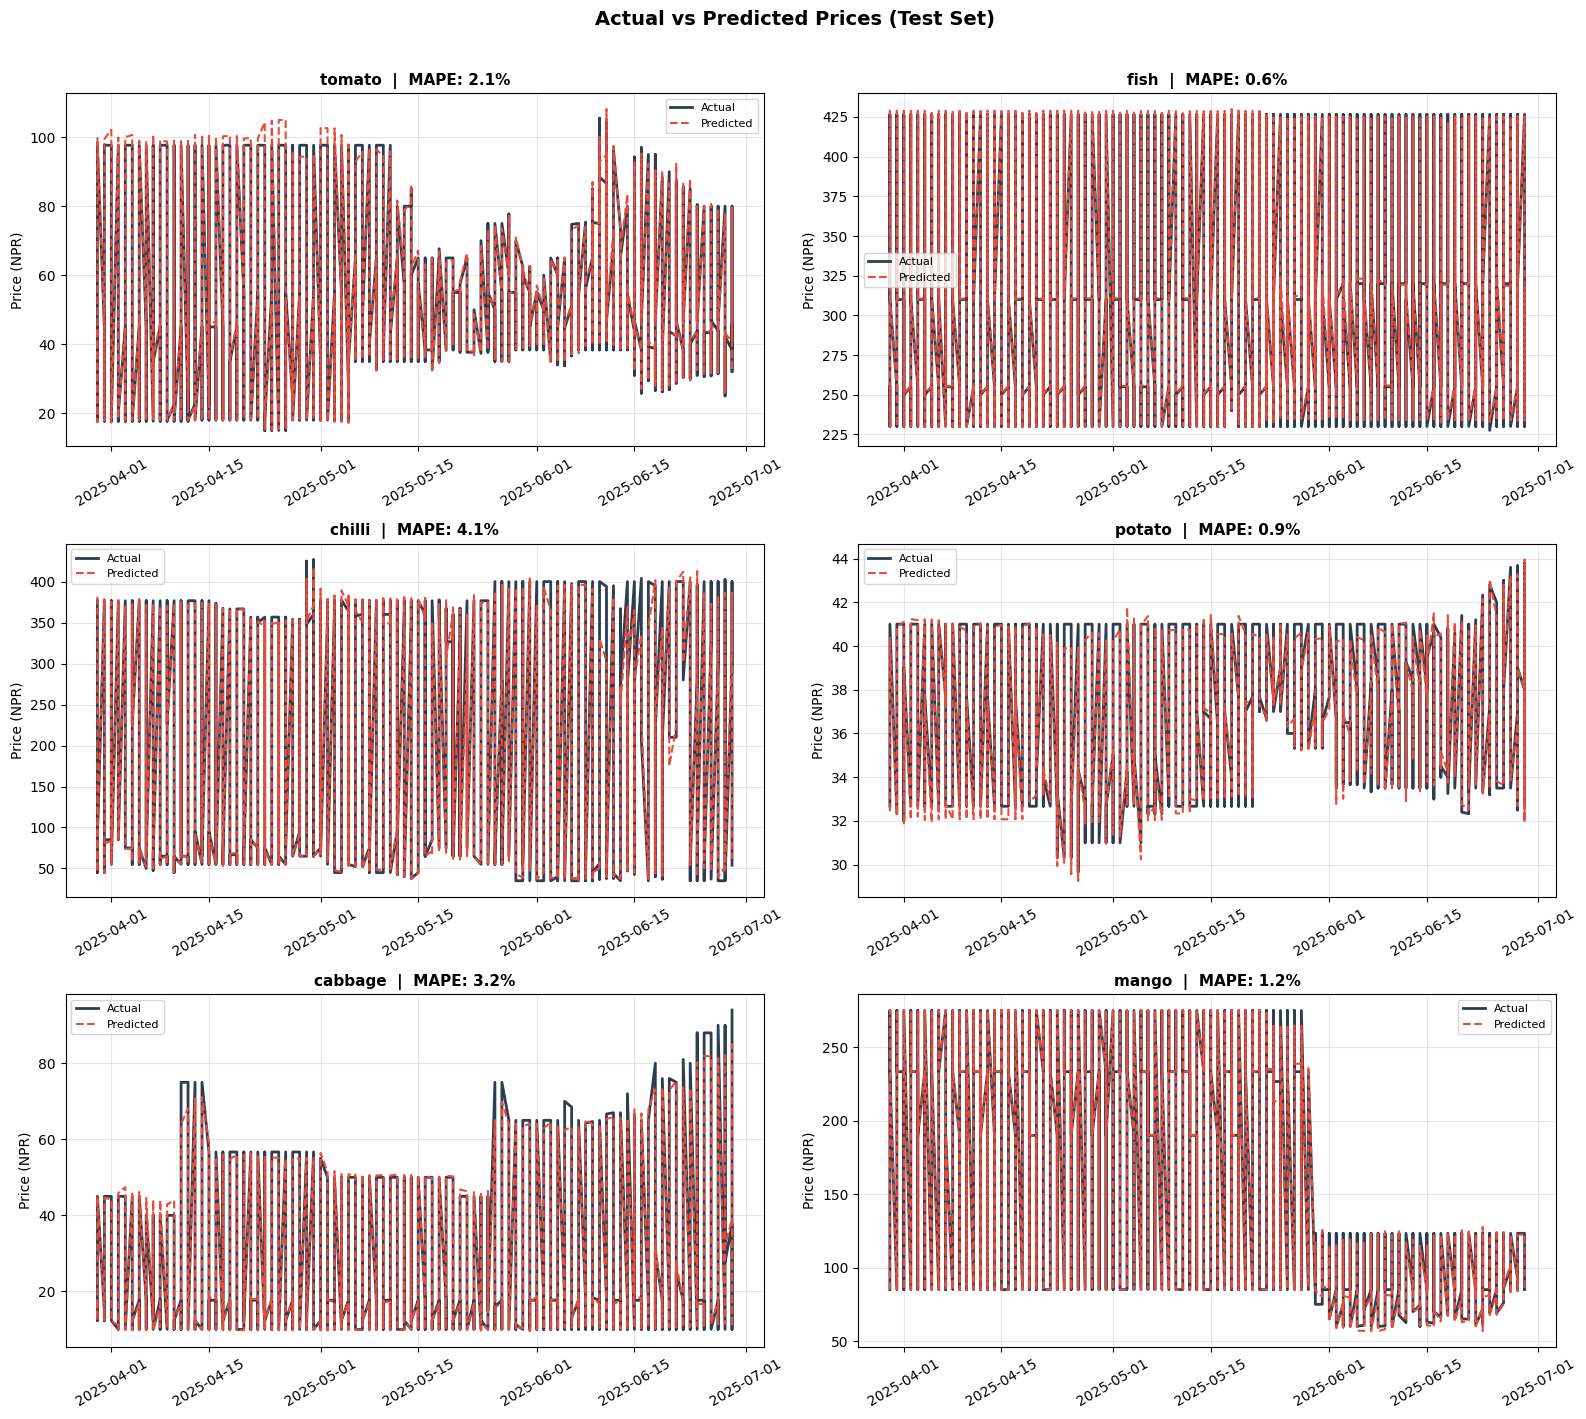

In [ ]:
# Pick top 6 most common vegetables in test set
top_vegs = test_results.groupby('name').size().sort_values(ascending=False).head(6).index.tolist()

fig, axes = plt.subplots(3, 2, figsize=(16, 14))
axes = axes.flatten()

for i, veg in enumerate(top_vegs):
    veg_data = test_results[test_results['name'] == veg].sort_values('date')
    ax = axes[i]
    ax.plot(veg_data['date'], veg_data['average'],
            label='Actual', color='#2C3E50', linewidth=2)
    ax.plot(veg_data['date'], veg_data['predicted'],
            label='Predicted', color='#E74C3C', linewidth=1.5, linestyle='--')
    veg_mape = veg_data['abs_pct_error'].mean()
    ax.set_title(f'{veg}  |  MAPE: {veg_mape:.1f}%', fontweight='bold', fontsize=11)
    ax.set_ylabel('Price (NPR)')
    ax.legend(fontsize=8)
    ax.tick_params(axis='x', rotation=30)
    ax.grid(True, alpha=0.3)

plt.suptitle('Actual vs Predicted Prices (Test Set)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()

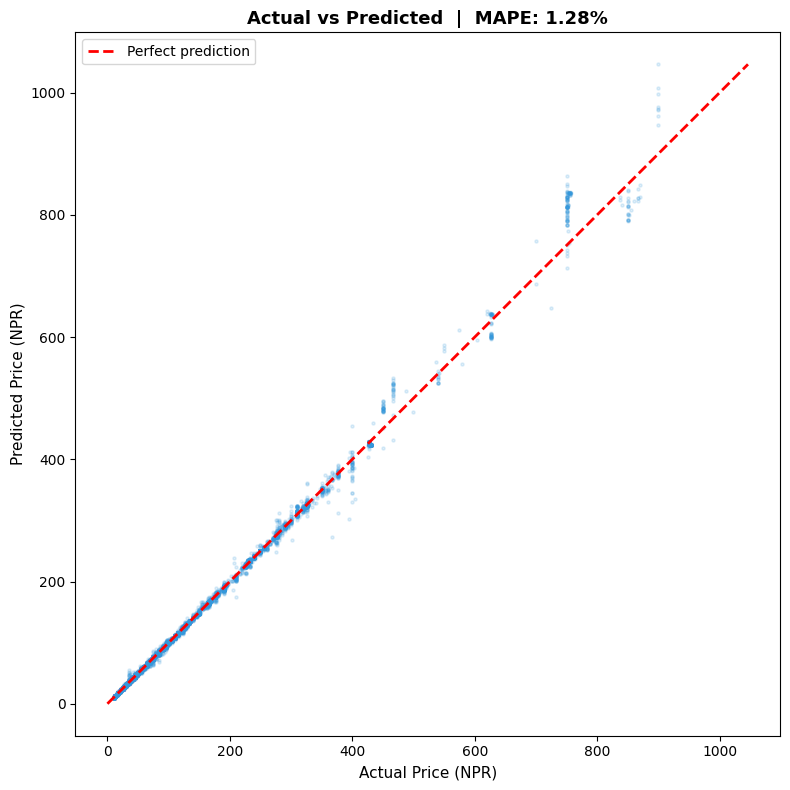

In [ ]:
# Scatter: Actual vs Predicted (all vegetables)
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(y_true_price, y_pred_price, alpha=0.15, s=5, color='#3498DB')
max_val = max(y_true_price.max(), y_pred_price.max())
ax.plot([0, max_val], [0, max_val], 'r--', linewidth=2, label='Perfect prediction')
ax.set_xlabel('Actual Price (NPR)', fontsize=11)
ax.set_ylabel('Predicted Price (NPR)', fontsize=11)
ax.set_title(f'Actual vs Predicted  |  MAPE: {mape:.2f}%', fontweight='bold', fontsize=13)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

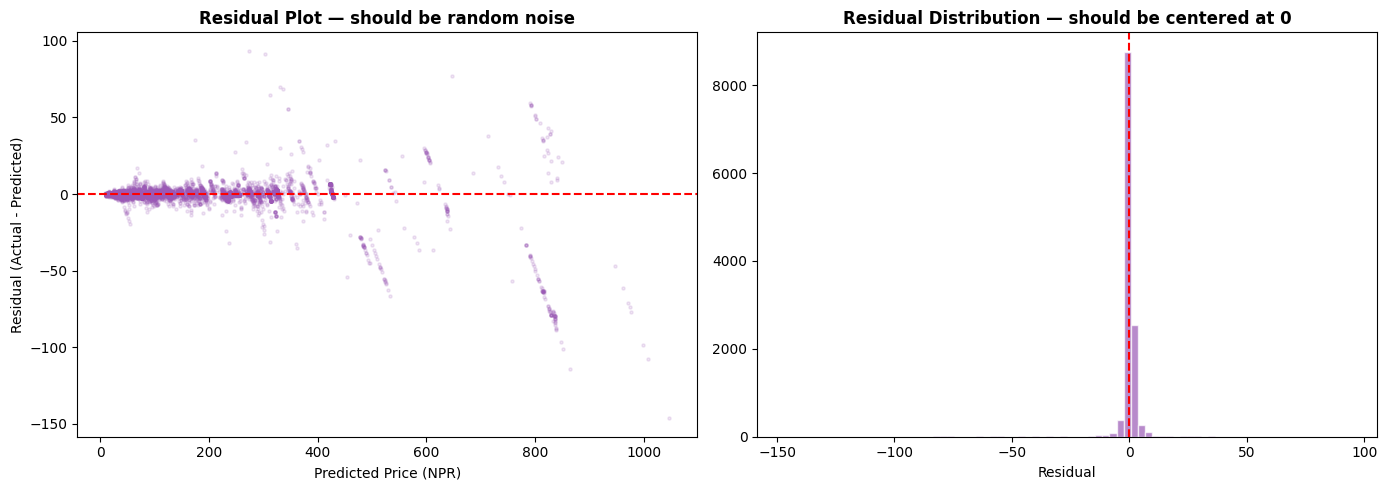

Residual mean : -0.4057 (ideal = 0)
Residual std  : 7.73


In [ ]:
# Residual plot
residuals = y_true_price - y_pred_price
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.scatter(y_pred_price, residuals, alpha=0.15, s=5, color='#9B59B6')
ax1.axhline(0, color='red', linestyle='--', linewidth=1.5)
ax1.set_xlabel('Predicted Price (NPR)')
ax1.set_ylabel('Residual (Actual - Predicted)')
ax1.set_title('Residual Plot — should be random noise', fontweight='bold')

ax2.hist(residuals, bins=80, color='#9B59B6', alpha=0.7, edgecolor='white')
ax2.axvline(0, color='red', linestyle='--', linewidth=1.5)
ax2.set_xlabel('Residual')
ax2.set_title('Residual Distribution — should be centered at 0', fontweight='bold')

plt.tight_layout()
plt.show()
print(f'Residual mean : {residuals.mean():.4f} (ideal = 0)')
print(f'Residual std  : {residuals.std():.2f}')

## ⚙️ Step 10 — Hyperparameter Tuning with Optuna

> This takes 10–30 minutes. Run after the baseline model works well.
> Uses **TimeSeriesSplit** to avoid data leakage during tuning.

In [ ]:
# from sklearn.model_selection import TimeSeriesSplit

# def objective(trial):
#     params = {
#         'n_estimators':      trial.suggest_int('n_estimators', 500, 3000),
#         'max_depth':         trial.suggest_int('max_depth', 3, 10),
#         'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
#         'subsample':         trial.suggest_float('subsample', 0.5, 1.0),
#         'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.5, 1.0),
#         'min_child_weight':  trial.suggest_int('min_child_weight', 1, 20),
#         'reg_alpha':         trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
#         'reg_lambda':        trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
#         'tree_method': 'hist',
#         'eval_metric': 'rmse',
#         'random_state': 42,
#         'n_jobs': -1,
#     }

#     tscv = TimeSeriesSplit(n_splits=5)
#     maes = []
#     for tr_idx, val_idx in tscv.split(X_train):
#         Xtr, Xval = X_train.iloc[tr_idx], X_train.iloc[val_idx]
#         ytr, yval = y_train.iloc[tr_idx], y_train.iloc[val_idx]
#         m = xgb.XGBRegressor(**params)
#         m.fit(Xtr, ytr, eval_set=[(Xval, yval)], verbose=False)
#         preds = np.expm1(m.predict(Xval))
#         actuals = np.expm1(yval.values)
#         mae = mean_absolute_error(actuals, preds)
#         maes.append(mae)
#     return np.mean(maes)

# study = optuna.create_study(direction='minimize')
# study.optimize(objective, n_trials=50, show_progress_bar=True)

# print('\nBest params:')
# for k, v in study.best_params.items():
#     print(f'  {k}: {v}')
# print(f'Best MAE: {study.best_value:.2f} NPR')

  0%|          | 0/50 [00:00<?, ?it/s]

[W 2026-03-06 07:10:39,649] Trial 21 failed with parameters: {'n_estimators': 2527, 'max_depth': 8, 'learning_rate': 0.04420528182981449, 'subsample': 0.6585349959754331, 'colsample_bytree': 0.7988690837809201, 'min_child_weight': 13, 'reg_alpha': 5.208889699011125e-07, 'reg_lambda': 1.78040245049697e-08} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/optuna/study/_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "/tmp/ipykernel_1314/2052746005.py", line 25, in objective
    m.fit(Xtr, ytr, eval_set=[(Xval, yval)], verbose=False)
  File "/usr/local/lib/python3.12/dist-packages/xgboost/core.py", line 751, in inner_f
    return func(**kwargs)
           ^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/xgboost/sklearn.py", line 1368, in fit
    self._Booster = train(
                    ^^^^^^
  File "/usr/local/lib/python3.

KeyboardInterrupt: 

In [ ]:
# Retrain on full training data with best params
best_params = study.best_params
best_params.update({'tree_method': 'hist', 'random_state': 42, 'n_jobs': -1})

best_model = xgb.XGBRegressor(**best_params)
best_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=100
)

# Re-evaluate
y_pred_best = np.expm1(best_model.predict(X_test))
mae_best    = mean_absolute_error(y_true_price, y_pred_best)
rmse_best   = np.sqrt(mean_squared_error(y_true_price, y_pred_best))
mape_best   = np.mean(np.abs((y_true_price - y_pred_best) / (y_true_price + 1e-9))) * 100

print('\n' + '='*45)
print('   TUNED MODEL RESULTS')
print('='*45)
print(f'  MAE  : {mae_best:.2f} NPR   (was {mae:.2f})')
print(f'  RMSE : {rmse_best:.2f} NPR   (was {rmse:.2f})')
print(f'  MAPE : {mape_best:.2f}%       (was {mape:.2f}%)')
print('='*45)

[0]	validation_0-rmse:0.85381
[100]	validation_0-rmse:0.03990
[200]	validation_0-rmse:0.03050
[300]	validation_0-rmse:0.02814
[400]	validation_0-rmse:0.02684
[500]	validation_0-rmse:0.02599
[600]	validation_0-rmse:0.02535
[700]	validation_0-rmse:0.02489
[800]	validation_0-rmse:0.02452
[900]	validation_0-rmse:0.02429
[1000]	validation_0-rmse:0.02404
[1100]	validation_0-rmse:0.02387
[1200]	validation_0-rmse:0.02368
[1300]	validation_0-rmse:0.02350
[1400]	validation_0-rmse:0.02333
[1500]	validation_0-rmse:0.02320
[1600]	validation_0-rmse:0.02311
[1700]	validation_0-rmse:0.02301
[1800]	validation_0-rmse:0.02294
[1900]	validation_0-rmse:0.02287
[2000]	validation_0-rmse:0.02277
[2100]	validation_0-rmse:0.02271
[2200]	validation_0-rmse:0.02265
[2300]	validation_0-rmse:0.02258
[2400]	validation_0-rmse:0.02251
[2500]	validation_0-rmse:0.02246
[2600]	validation_0-rmse:0.02242
[2700]	validation_0-rmse:0.02235
[2745]	validation_0-rmse:0.02234

   TUNED MODEL RESULTS
  MAE  : 1.65 NPR   (was 1.97)


## 💾 Step 11 — Save Model & Label Encoder

In [ ]:
import joblib

# Save the tuned model (use base model if you skipped Optuna)
final_model = best_model  # or: final_model = model

joblib.dump(final_model, '/content/drive/MyDrive/nepal_veg_price_xgboost.pkl')
joblib.dump(le,          '/content/drive/MyDrive/nepal_veg_label_encoder.pkl')
joblib.dump(FEATURE_COLS,'/content/drive/MyDrive/nepal_veg_feature_cols.pkl')

print('✅ Model saved!')
print('✅ Label encoder saved!')
print('✅ Feature columns saved!')

✅ Model saved!
✅ Label encoder saved!
✅ Feature columns saved!


## 🔮 Bonus — Predict Future Prices

In [ ]:
def predict_price(vegetable_name, target_date, df_history, model, le, feature_cols):
    """
    Predict the average price of a vegetable on a given future date.
    Requires recent historical data for lag computation.
    """
    target_date = pd.to_datetime(target_date)

    # Get last 30 days of history for this vegetable
    hist = df_history[df_history['name'] == vegetable_name].sort_values('date').tail(30)

    row = {}

    # Date features
    row['month']      = target_date.month
    row['day']        = target_date.day
    row['year']       = target_date.year
    row['dayofweek']  = target_date.dayofweek
    row['weekofyear'] = target_date.isocalendar()[1]
    row['dayofyear']  = target_date.timetuple().tm_yday

    # Calendar features (reuse maps)
    m = row['month']; d = row['day']
    season_map_local = {1:1,2:1,3:2,4:2,5:3,6:4,7:4,8:4,9:5,10:6,11:6,12:1}
    row['season_code'] = season_map_local[m]
    row['is_winter']   = int(row['season_code']==1)
    row['is_spring']   = int(row['season_code']==2)
    row['is_summer']   = int(row['season_code']==3)
    row['is_monsoon']  = int(row['season_code']==4)
    row['is_autumn']   = int(row['season_code']==5)
    row['is_prewin']   = int(row['season_code']==6)
    monsoon_map_local  = {1:0,2:0,3:0,4:0,5:0.5,6:2,7:3,8:2.5,9:1,10:0,11:0,12:0}
    row['monsoon_intensity'] = monsoon_map_local[m]
    row['is_asar']    = int(m==6); row['is_shrawan'] = int(m==7); row['is_bhadra'] = int(m==8)
    supply_map_local   = {1:1,2:1,3:0,4:0,5:-0.5,6:-1,7:-1,8:-0.5,9:0.5,10:1,11:0.5,12:0}
    row['supply_score']          = supply_map_local[m]
    row['is_rice_planting']      = int(m in [6,7])
    row['is_rice_harvest']       = int(m in [10,11])
    row['is_winter_veg_harvest'] = int(m in [1,2])
    row['is_dashain_window']     = int(m==10 and d<=20)
    row['is_tihar_window']       = int((m==10 and d>=20) or (m==11 and d<=5))
    row['is_holi_window']        = int(m==3 and d<=15)
    row['is_maghe_window']       = int(m==1 and 13<=d<=15)
    row['is_chhath_window']      = int(m==11 and d<=10)
    row['is_shivaratri_win']     = int((m==2 and d>=15) or (m==3 and d<=5))
    row['is_any_festival']       = int(row['is_dashain_window'] or row['is_tihar_window'] or
                                       row['is_holi_window'] or row['is_chhath_window'])
    row['festival_demand_weight']= (row['is_dashain_window']*1.5 + row['is_tihar_window']*1.2 +
                                    row['is_holi_window']*0.6    + row['is_chhath_window']*0.5)
    row['is_saturday']    = int(row['dayofweek']==5)
    row['is_monday']      = int(row['dayofweek']==0)
    row['is_month_start'] = int(d<=5)
    row['is_month_end']   = int(d>=26)
    row['month_sin']      = np.sin(2*np.pi*m/12)
    row['month_cos']      = np.cos(2*np.pi*m/12)
    row['dayofweek_sin']  = np.sin(2*np.pi*row['dayofweek']/7)
    row['dayofweek_cos']  = np.cos(2*np.pi*row['dayofweek']/7)
    row['weekofyear_sin'] = np.sin(2*np.pi*row['weekofyear']/52)
    row['weekofyear_cos'] = np.cos(2*np.pi*row['weekofyear']/52)
    row['dayofyear_sin']  = np.sin(2*np.pi*row['dayofyear']/365)
    row['dayofyear_cos']  = np.cos(2*np.pi*row['dayofyear']/365)
    row['price_pressure_score'] = (
        row['monsoon_intensity']*0.4 + row['is_dashain_window']*1.5 +
        row['is_tihar_window']*1.2   + row['is_any_festival']*0.4  +
        row['is_winter']*0.5          + row['supply_score']*-1.0
    )

    # Lag features from history
    prices = hist['average'].values
    row['price_lag_1']    = prices[-1]  if len(prices)>=1  else np.nan
    row['price_lag_3']    = prices[-3]  if len(prices)>=3  else np.nan
    row['price_lag_7']    = prices[-7]  if len(prices)>=7  else np.nan
    row['price_lag_14']   = prices[-14] if len(prices)>=14 else np.nan
    row['price_lag_30']   = prices[-30] if len(prices)>=30 else np.nan
    row['rolling_mean_7'] = np.mean(prices[-7:])  if len(prices)>=7  else np.mean(prices)
    row['rolling_mean_14']= np.mean(prices[-14:]) if len(prices)>=14 else np.mean(prices)
    row['rolling_mean_30']= np.mean(prices[-30:]) if len(prices)>=30 else np.mean(prices)
    row['rolling_std_7']  = np.std(prices[-7:])   if len(prices)>=7  else 0
    row['rolling_std_14'] = np.std(prices[-14:])  if len(prices)>=14 else 0
    row['rolling_std_30'] = np.std(prices[-30:])  if len(prices)>=30 else 0
    row['rolling_min_7']  = np.min(prices[-7:])   if len(prices)>=7  else np.min(prices)
    row['rolling_max_7']  = np.max(prices[-7:])   if len(prices)>=7  else np.max(prices)
    row['rolling_min_30'] = np.min(prices[-30:])  if len(prices)>=30 else np.min(prices)
    row['rolling_max_30'] = np.max(prices[-30:])  if len(prices)>=30 else np.max(prices)
    row['price_change_1d'] = (prices[-1]-prices[-2])/prices[-2] if len(prices)>=2 else 0
    row['price_change_7d'] = (prices[-1]-prices[-7])/prices[-7] if len(prices)>=7 else 0
    row['price_change_30d']= (prices[-1]-prices[-30])/prices[-30] if len(prices)>=30 else 0
    row['price_range']     = hist['maximum'].iloc[-1] - hist['minimum'].iloc[-1] if len(hist)>=1 else 0
    row['price_range_lag1']= hist['maximum'].iloc[-2] - hist['minimum'].iloc[-2] if len(hist)>=2 else 0
    row['name_encoded']    = le.transform([vegetable_name])[0]

    X_new = pd.DataFrame([row])[feature_cols]
    pred  = np.expm1(model.predict(X_new)[0])
    return round(pred, 2)


# ── Example usage ──────────────────────────────────────────
vegetables_to_predict = ['tomato', 'potato', 'onion']
future_date = '2025-03-15'

print(f'Predicted prices for {future_date}:')
print('-' * 35)
for veg in vegetables_to_predict:
    try:
        price = predict_price(veg, future_date, df, final_model, le, FEATURE_COLS)
        print(f'  {veg:20s}: {price:>8.2f} NPR')
    except Exception as e:
        print(f'  {veg:20s}: Error — {e}')

Predicted prices for 2025-03-15:
-----------------------------------
  tomato              :    49.86 NPR
  potato              :    29.50 NPR
  onion               :   104.41 NPR


## ✅ Pipeline Complete!

```
Step 1  Load data                     ✅
Step 2  Clean (zeros, outliers)       ✅
Step 3  Lag & rolling features        ✅
Step 4  Log-transform target          ✅
Step 5  Time-based train/test split   ✅
Step 6  XGBoost + early stopping      ✅
Step 7  MAE / RMSE / MAPE eval        ✅
Step 8  Feature importance            ✅
Step 9  Actual vs Predicted plots     ✅
Step 10 Optuna tuning                 ✅
Step 11 Save model                    ✅
Bonus   Predict future prices         ✅
```

**Target MAPE: < 10% = Excellent | < 15% = Good**